Current working directory: /home/thien/Desktop/Workspace/PersonalDevelopment/ObjectDetection/Surface-Defect-Detection/notebooks
Data directory: ../data/raw/NEU-DET
Dataset exists: True
Class distribution: {'crazing': 300, 'inclusion': 300, 'patches': 300, 'pitted_surface': 300, 'rolled-in_scale': 300, 'scratches': 300}


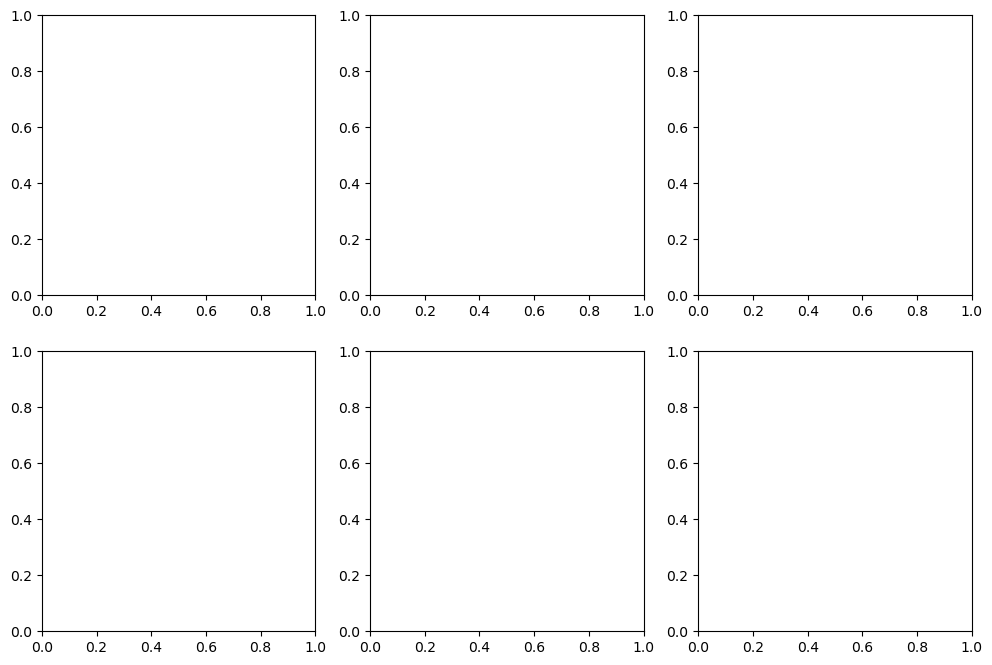

In [2]:
# notebooks/01_eda.ipynb - chạy cell này để verify

import os
from pathlib import Path
import matplotlib.pyplot as plt
import cv2

data_dir = Path("../data/raw/NEU-DET")

print("Current working directory:", Path.cwd())
print("Data directory:", data_dir)
print("Dataset exists:", data_dir.exists())

# Đếm ảnh theo class
class_counts = {}
for split in ["train", "validation"]:
    for split2 in ["crazing", "inclusion", "patches", "pitted_surface", "rolled-in_scale", "scratches"]:
        class_dir = data_dir / split / "images" / split2 
        if class_dir.exists():
            count = len(list(class_dir.glob("*.jpg")))
            class_counts[split2] = class_counts.get(split2, 0) + count


print("Class distribution:", class_counts)

# Visualize sample images
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
class_dirs = list(data_dir.glob("**/images"))
# ... (vẽ sample từ mỗi class)

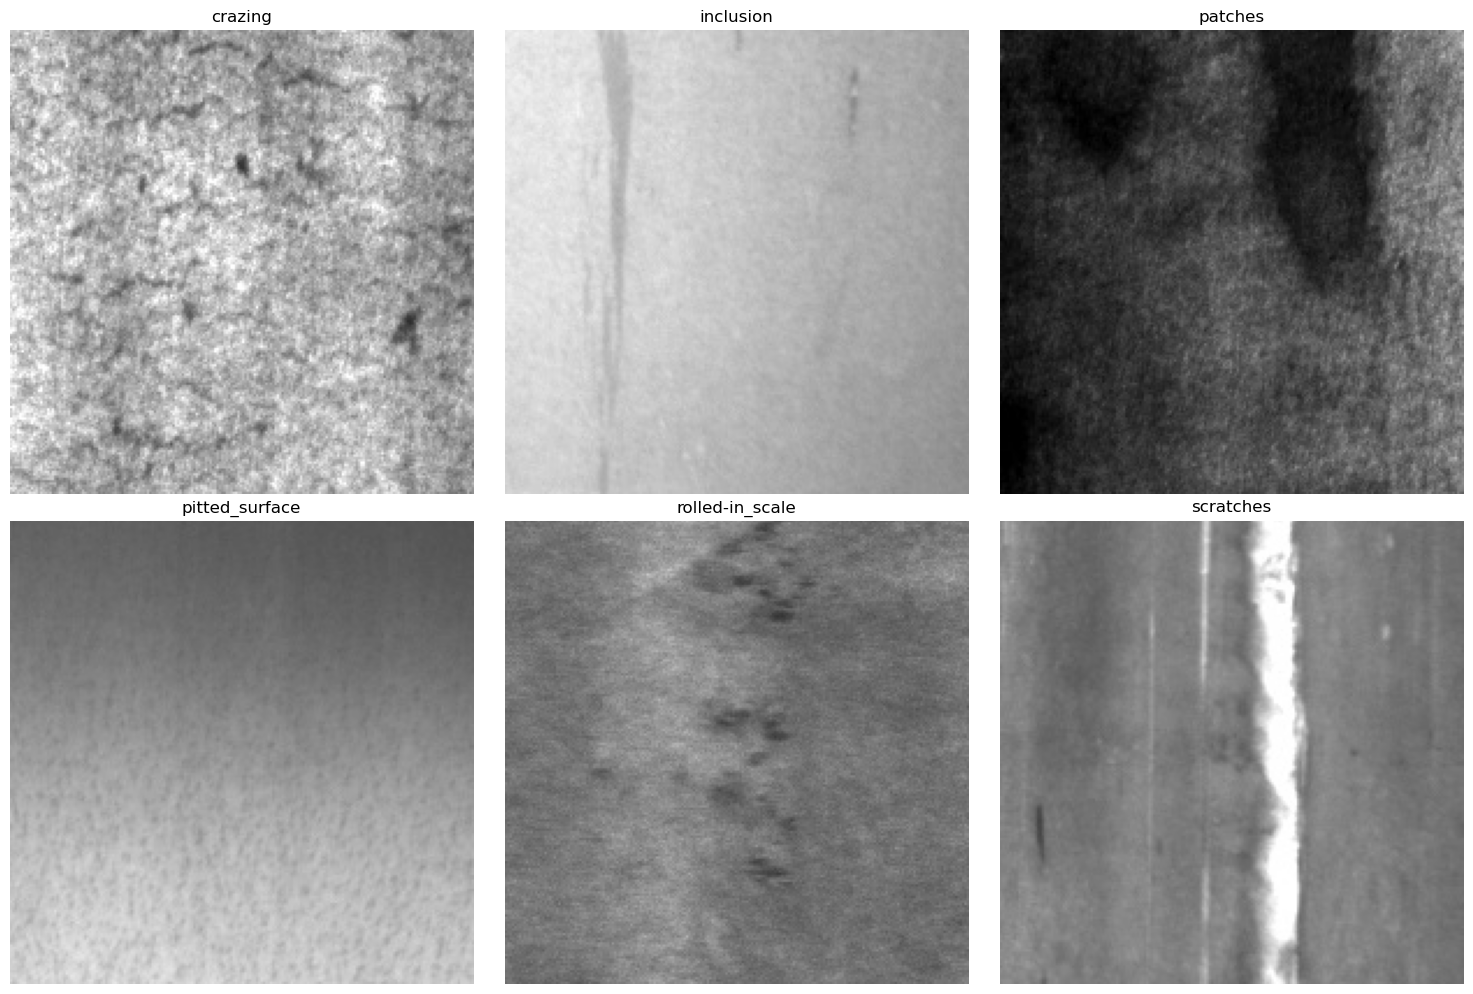

In [5]:
import random


train_images_dir = data_dir / "train" / "images"

## lay cac thu muc chua cac class tren tap train
class_dir = sorted([
    d for d in train_images_dir.iterdir()
    if d.is_dir()
])

fig, axes = plt.subplots(2,3, figsize = (15, 10))
axes = axes.ravel()


for ax, class_dir in zip(axes, class_dir):
    ## Lay toan bo anh tring class
    images_file = list(class_dir.glob("*.jpg"))
    
    if not images_file:
        ax.axis("off")
        continue
    
    ## chon ngau nhien 1 anh
    sample_path = random.choice(images_file)
    
    ## DOc anh bang opencv
    image = cv2.imread(str(sample_path))
    
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    ## hien thi anh
    ax.imshow(image)
    ax.set_title(class_dir.name)
    ax.axis("off")
    
plt.tight_layout()
plt.show()